# LEAP Quickstart: Europa Clipper Flyby Predictions (Local Testing)

This notebook allows you to:
1. Select a Europa Clipper flyby from the table below
2. Set plasma conditions (RhoO, H0, n0)
3. Generate magnetic field predictions with ±5% upstream field variability
4. Visualize results in 5-panel plot

**Note:** Using local CSV for testing before HuggingFace deployment.

## Setup

In [1]:
import sys
from pathlib import Path

# Add parent directory to import LEAP modules
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

from model.transformer import Lightweight
from utils.hf_artifacts import download_model_artifacts, download_flybys_csv

print(f"✅ Python: {sys.version.split()[0]} | PyTorch: {torch.__version__}")

✅ Python: 3.13.9 | PyTorch: 2.9.1


## Load Pretrained Model

In [2]:
# Download model artifacts from HuggingFace
print("[Model] Downloading pretrained artifacts from HuggingFace...")
artifacts = download_model_artifacts(repo_id="reddysachin/LEAP")

# Load scaler
with open(artifacts['scaler'], 'rb') as f:
    scaler = pickle.load(f)
print(f"[Model] Loaded scaler from {artifacts['scaler']}")

# Initialize and load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Lightweight(
    input_dim=11,  # x1, y1, z1, R, Bx_U, By_U, Bz_U, M, RhoO, H0, n0
    d_model=32,
    nhead=2,
    num_layers=2,
    dropout=0.0,
    dim_feedforward=4096
).to(device)

model.load_state_dict(torch.load(artifacts['weights'], map_location=device, weights_only=True))
model.eval()
print(f"[Model] Loaded model weights from {artifacts['weights']}")
print(f"[Model] Running on: {device}")

[Model] Downloading pretrained artifacts from HuggingFace...
[HF] Model repo: reddysachin/LEAP
[HF] Downloading leap_weights.pt ...
[HF] Ready: leap_weights.pt
[HF] Downloading leap_scaler.pkl ...
[HF] Ready: leap_scaler.pkl
[HF] Model artifacts ready
[Model] Loaded scaler from /Users/sareddy/.cache/huggingface/hub/models--reddysachin--LEAP/snapshots/7012d6cc1f453e784ebee6b56c9a25ad9381f8ef/leap_scaler.pkl
[Model] Loaded model weights from /Users/sareddy/.cache/huggingface/hub/models--reddysachin--LEAP/snapshots/7012d6cc1f453e784ebee6b56c9a25ad9381f8ef/leap_weights.pt
[Model] Running on: cpu


## Load Flyby Data from HuggingFace

Loading Europa Clipper flybys from HuggingFace dataset containing trajectory (x1, y1, z1, R), upstream field (Bx_U, By_U, Bz_U, M), and Jupiter background field (Bx_BJ, By_BJ, Bz_BJ).

In [3]:
# Download flybys CSV from HuggingFace
print("[Data] Downloading flybys from HuggingFace...")
flybys_csv_path = download_flybys_csv(
    repo_id="reddysachin/Europa_Clipper_Tour",
    filename="clipper_tour_with_BJ.csv"
)

flybys_df = pd.read_csv(flybys_csv_path)
print(f"✓ Loaded {len(flybys_df)} trajectory points from {len(flybys_df['flyby'].unique())} flybys\n")

# Get flyby summary
flyby_summary = []
for flyby_id in sorted(flybys_df['flyby'].unique()):
    fb_data = flybys_df[flybys_df['flyby'] == flyby_id]
    ca_idx = fb_data['E_alt'].idxmin()
    ca_row = fb_data.loc[ca_idx]
    flyby_summary.append({
        'Flyby': flyby_id,
        'Date': ca_row['utc'].split()[0],
        'CA (km)': f"{ca_row['E_alt']:.1f}",
        'Points': len(fb_data)
    })

summary_df = pd.DataFrame(flyby_summary)
print("Available Europa Clipper Flybys:")
print("=" * 50)
print(summary_df.to_string(index=False))
print("=" * 50)

[Data] Downloading flybys from HuggingFace...
[HF] Flybys repo: reddysachin/Europa_Clipper_Tour
[HF] Downloading clipper_tour_with_BJ.csv ...
[HF] Ready: clipper_tour_with_BJ.csv
[HF] Flybys CSV ready
✓ Loaded 23053 trajectory points from 48 flybys

Available Europa Clipper Flybys:
 Flyby       Date CA (km)  Points
08-E03 2031-05-27    50.0     480
09-E04 2031-06-17    49.4     480
10-E05 2031-07-09    51.0     480
11-E06 2031-07-30    36.8     480
12-E07 2031-08-20    86.4     480
13-E08 2031-09-11    50.1     480
14-E09 2031-10-02    98.9     480
15-E10 2031-10-23    23.9     481
16-E11 2031-11-14    35.4     481
17-E12 2031-12-05    66.7     481
19-E13 2032-01-20    51.8     481
20-E14 2032-02-11    35.2     481
21-E15 2032-03-03    98.8     481
23-E17 2032-04-11    26.2     480
24-E18 2032-04-26    76.4     480
25-E19 2032-05-13    51.5     480
26-E20 2032-05-28   101.0     480
27-E21 2032-06-14    36.5     480
28-E22 2032-06-29    76.5     480
29-E23 2032-07-16    26.5     480
30-

In [4]:
def apply_upstream_variability(flyby_df, variability_percent=0.05):
    """
    Apply ±variability to upstream field parameters and recalculate M.
    
    Args:
        flyby_df: DataFrame with Bx_U, By_U, Bz_U, M columns
        variability_percent: Fractional variability (0.05 = 5%)
    
    Returns:
        Modified dataframe with perturbed upstream fields
    """
    df = flyby_df.copy()
    
    # Get median values at closest approach
    ca_idx = df['E_alt'].idxmin()
    Bx_U_median = df.loc[ca_idx, 'Bx_U']
    By_U_median = df.loc[ca_idx, 'By_U']
    Bz_U_median = df.loc[ca_idx, 'Bz_U']
    
    # Calculate variability ranges
    Bx_range = abs(Bx_U_median * variability_percent)
    By_range = abs(By_U_median * variability_percent)
    Bz_range = abs(Bz_U_median * variability_percent)
    
    # Apply random perturbation within range (constant for entire trajectory)
    Bx_U_new = np.random.uniform(Bx_U_median - Bx_range, Bx_U_median + Bx_range)
    By_U_new = np.random.uniform(By_U_median - By_range, By_U_median + By_range)
    Bz_U_new = np.random.uniform(Bz_U_median - Bz_range, Bz_U_median + Bz_range)
    
    # Broadcast to all timesteps
    df['Bx_U'] = Bx_U_new
    df['By_U'] = By_U_new
    df['Bz_U'] = Bz_U_new
    
    # Recalculate M (proportionally scaled from original)
    M_original = df.loc[ca_idx, 'M']
    B_original_mag = np.sqrt(Bx_U_median**2 + By_U_median**2 + Bz_U_median**2)
    B_new_mag = np.sqrt(Bx_U_new**2 + By_U_new**2 + Bz_U_new**2)
    M_new = M_original * (B_original_mag / B_new_mag)  # M ∝ 1/B
    df['M'] = M_new
    
    return df

def prepare_features(flyby_df, RhoO, H0, n0):
    """
    Prepare features for LEAP model.
    
    Features: [x1, y1, z1, R, Bx_U, By_U, Bz_U, M, RhoO, H0, n0]
    """
    df = flyby_df.copy()
    
    # Ensure R column exists
    if 'R' not in df.columns:
        df['R'] = np.sqrt(df['x1']**2 + df['y1']**2 + df['z1']**2)
    
    # Add user-defined plasma parameters
    df['RhoO'] = RhoO
    df['H0'] = H0
    df['n0'] = n0
    
    # Select features in correct order
    feature_cols = ['x1', 'y1', 'z1', 'R', 'Bx_U', 'By_U', 'Bz_U', 'M', 'RhoO', 'H0', 'n0']
    features = df[feature_cols].values
    
    # Scale using pretrained scaler
    features_scaled = scaler.transform(features)
    
    return features_scaled, df

def predict_magnetic_field(flyby_df, RhoO, H0, n0, apply_variability=True, variability_percent=0.05):
    """
    Generate magnetic field predictions along trajectory.
    
    Returns:
        df_with_preds: DataFrame with trajectory, predictions, and total fields
    """
    # Apply upstream field variability
    if apply_variability:
        flyby_df = apply_upstream_variability(flyby_df, variability_percent)
    
    # Prepare features
    features_scaled, df = prepare_features(flyby_df, RhoO, H0, n0)
    
    # Convert to tensor
    X = torch.tensor(features_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate predictions
    with torch.no_grad():
        predictions = model(X).squeeze(0).cpu().numpy()  # Shape: (seq_len, 3)
    
    # Add predictions to dataframe
    df['delta_Bx'] = predictions[:, 0]
    df['delta_By'] = predictions[:, 1]
    df['delta_Bz'] = predictions[:, 2]
    
    # Calculate total field: prediction + Jupiter background
    df['Bx_total'] = df['delta_Bx'] + df['Bx_BJ']
    df['By_total'] = df['delta_By'] + df['By_BJ']
    df['Bz_total'] = df['delta_Bz'] + df['Bz_BJ']
    df['B_total_mag'] = np.sqrt(df['Bx_total']**2 + df['By_total']**2 + df['Bz_total']**2)
    
    return df

In [5]:
def plot_predictions_5panel(df, flyby_name):
    """
    5-panel plot: R_europa, Bx, By, Bz, |B|
    Components show: prediction (delta) + Jupiter background (BJ) = total
    """
    import matplotlib.dates as mdates
    
    FONT_SIZE = 11
    
    # Reset index to ensure proper alignment
    df = df.reset_index(drop=True)
    
    # Find closest approach index (positional)
    ca_idx = df['E_alt'].argmin()
    
    # Convert UTC to datetime
    df['datetime'] = pd.to_datetime(df['utc'])
    ca_time = df['datetime'].iloc[ca_idx]
    
    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"{flyby_name} Summary")
    print(f"{'='*60}")
    print(f"\nClosest Approach:")
    print(f"  • Altitude: {df.iloc[ca_idx]['E_alt']:.1f} km")
    print(f"  • Date: {df.iloc[ca_idx]['utc']}")
    print(f"\nPerturbations at C/A:")
    print(f"  • δBx: {df.iloc[ca_idx]['delta_Bx']:.2f} nT")
    print(f"  • δBy: {df.iloc[ca_idx]['delta_By']:.2f} nT")
    print(f"  • δBz: {df.iloc[ca_idx]['delta_Bz']:.2f} nT")
    print(f"\nTotal Field at C/A:")
    print(f"  • Bx: {df.iloc[ca_idx]['Bx_total']:.2f} nT")
    print(f"  • By: {df.iloc[ca_idx]['By_total']:.2f} nT")
    print(f"  • Bz: {df.iloc[ca_idx]['Bz_total']:.2f} nT")
    print(f"  • |B|: {df.iloc[ca_idx]['B_total_mag']:.2f} nT")
    print(f"\nUpstream Conditions:")
    print(f"  • Bx_U: {df.iloc[ca_idx]['Bx_U']:.2f} nT")
    print(f"  • By_U: {df.iloc[ca_idx]['By_U']:.2f} nT")
    print(f"  • Bz_U: {df.iloc[ca_idx]['Bz_U']:.2f} nT")
    print(f"  • M: {df.iloc[ca_idx]['M']:.2f}")
    print(f"{'='*60}\n")
    
    # Create relative time ticks at 5-minute intervals from -20 to +20
    rel_times = [-20, -15, -10, -5, 0, 5, 10, 15, 20]  # minutes
    tick_times = [ca_time + pd.Timedelta(minutes=rt) for rt in rel_times]
    tick_labels = [f'{rt:+d}' if rt != 0 else 'C/A' for rt in rel_times]
    
    # Create figure with 5 rows, 1 column, custom height ratios
    fig, axes = plt.subplots(5, 1, figsize=(9, 9), sharex=True, 
                            gridspec_kw={'height_ratios': [0.7, 1, 1, 1, 1]})
    
    # Panel 1: R (Europa Radius)
    ax = axes[0]
    ax.plot(df['datetime'], df['R'], linewidth=2, color='steelblue')
    ax.set_ylabel('$R_E$', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE)
    
    # Add relative time labels on top of first panel only
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(tick_times)
    ax2.set_xticklabels(tick_labels)
    ax2.set_xlabel('Time from C/A (min)', fontsize=FONT_SIZE, labelpad=10)
    ax2.tick_params(labelsize=FONT_SIZE)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(False)
    
    # Panel 2: Bx
    ax = axes[1]
    line_bj = ax.plot(df['datetime'], df['Bx_BJ'], linestyle='--', alpha=0.6, color='gray', label='BJ')[0]
    line_total = ax.plot(df['datetime'], df['Bx_total'], linewidth=2, color='steelblue', label='Pred + BJ')[0]
    ax.set_ylabel('Bx [nT]', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE)
    
    # Panel 3: By
    ax = axes[2]
    ax.plot(df['datetime'], df['By_BJ'], linestyle='--', alpha=0.6, color='gray')
    ax.plot(df['datetime'], df['By_total'], linewidth=2, color='steelblue')
    ax.set_ylabel('By [nT]', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE)
    
    # Panel 4: Bz
    ax = axes[3]
    ax.plot(df['datetime'], df['Bz_BJ'], linestyle='--', alpha=0.6, color='gray')
    ax.plot(df['datetime'], df['Bz_total'], linewidth=2, color='steelblue')
    ax.set_ylabel('Bz [nT]', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE)
    
    # Panel 5: |B| magnitude
    ax = axes[4]
    B_BJ_mag = np.sqrt(df['Bx_BJ']**2 + df['By_BJ']**2 + df['Bz_BJ']**2)
    ax.plot(df['datetime'], B_BJ_mag, linestyle='--', alpha=0.6, color='gray')
    ax.plot(df['datetime'], df['B_total_mag'], linewidth=2, color='steelblue')
    ax.set_ylabel('|B| [nT]', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=FONT_SIZE)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    # Add horizontal legend at bottom
    fig.legend([line_total, line_bj], ['Pred ($\delta$) + $B_J$', '$B_J$'], 
               loc='lower center', ncol=2, fontsize=FONT_SIZE, 
               bbox_to_anchor=(0.5, -0.05), frameon=False)
    
    #plt.suptitle(f'LEAP Prediction: {flyby_name}', fontsize=FONT_SIZE, fontweight='normal', y=0.995)
    plt.tight_layout()
    plt.show()

## Run Predictions

### Plasma Parameter Ranges:
- **RhoO**: 320 - 2400 (Magnetospheric O+ mass density, amu/cm³)
- **H0**: 2.5×10⁷ - 7.5×10⁷ (Atmospheric scale height, km)
- **n0**: 33 - 330 (Atmospheric surface density, cm⁻³)

### Upstream Field Variability:
- ±5% applied to Bx_U, By_U, Bz_U at closest approach
- M recalculated based on new field magnitude

## Select Flyby and Set Parameters

Edit the values below and run the cell to generate predictions.

LEAP Prediction Setup
Flyby: 15-E10
Plasma conditions:
  • RhoO = 1000.0 amu/cm³
  • H0   = 5.00e+07 km
  • n0   = 40.0 cm⁻³
Upstream variability: Enabled (5%)

[1/3] Loaded 15-E10 with 481 trajectory points
[2/3] Generated predictions
[3/3] Plotting...

15-E10 Summary

Closest Approach:
  • Altitude: 23.9 km
  • Date: 2031-10-23 21:46:25

Perturbations at C/A:
  • δBx: -123.75 nT
  • δBy: -60.60 nT
  • δBz: -10.44 nT

Total Field at C/A:
  • Bx: -166.22 nT
  • By: -244.70 nT
  • Bz: -418.28 nT
  • |B|: 512.31 nT

Upstream Conditions:
  • Bx_U: -42.15 nT
  • By_U: -190.27 nT
  • Bz_U: -413.79 nT
  • M: 92.83



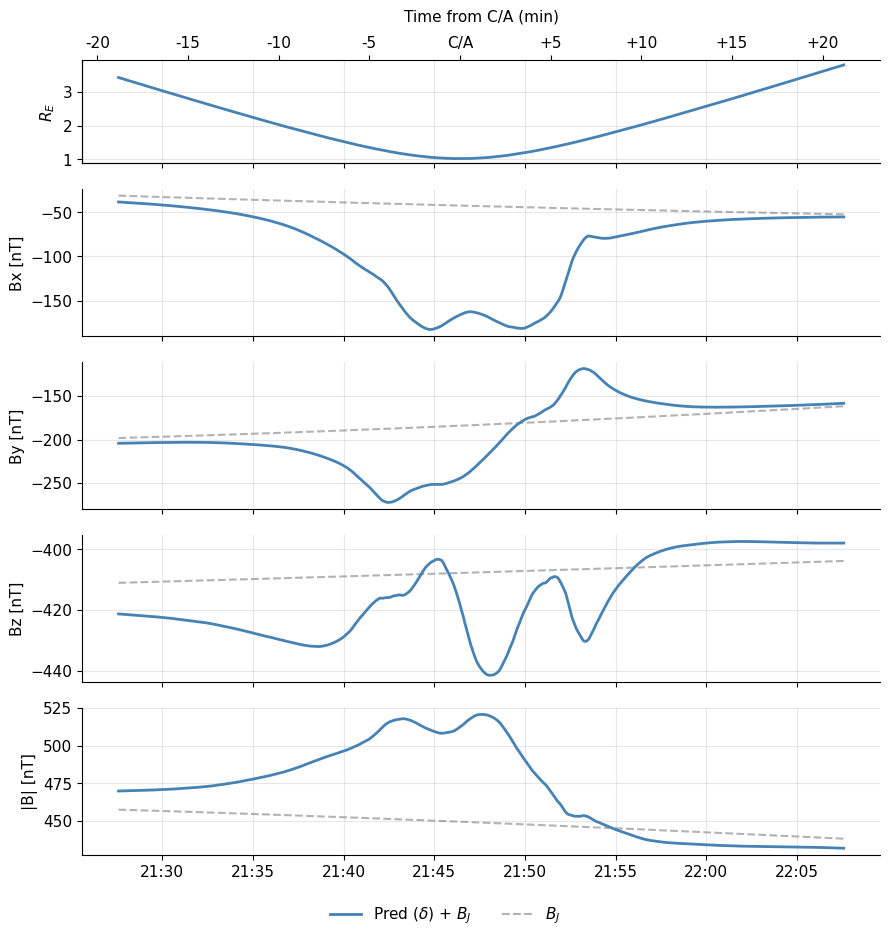


✓ Prediction complete! Results stored in 'last_prediction'


In [6]:
# ===== EDIT THESE VALUES =====
FLYBY_ID = '15-E10'  # Choose from table above

# Plasma parameters
RhoO = 1000      # Magnetospheric O+ mass density (320 - 2400 amu/cm³)
H0 = 5e7        # Atmospheric scale height (2.5e7 - 7.5e7 km)
n0 = 40        # Atmospheric surface density (33 - 330 cm⁻³)

# Upstream variability
APPLY_VARIABILITY = True   # Apply ±5% to upstream fields
VARIABILITY_PERCENT = 0.05  # 5% variability
# =============================

print(f"{'='*60}")
print(f"LEAP Prediction Setup")
print(f"{'='*60}")
print(f"Flyby: {FLYBY_ID}")
print(f"Plasma conditions:")
print(f"  • RhoO = {RhoO:.1f} amu/cm³")
print(f"  • H0   = {H0:.2e} km")
print(f"  • n0   = {n0:.1f} cm⁻³")
print(f"Upstream variability: {'Enabled' if APPLY_VARIABILITY else 'Disabled'} ({VARIABILITY_PERCENT*100:.0f}%)")
print(f"{'='*60}\n")

# Load selected flyby and reset index
flyby_df = flybys_df[flybys_df['flyby'] == FLYBY_ID].copy().reset_index(drop=True)
if len(flyby_df) == 0:
    raise ValueError(f"Flyby '{FLYBY_ID}' not found. Check table above for valid IDs.")

print(f"[1/3] Loaded {FLYBY_ID} with {len(flyby_df)} trajectory points")

# Make predictions
df_results = predict_magnetic_field(
    flyby_df, 
    RhoO=RhoO, 
    H0=H0, 
    n0=n0,
    apply_variability=APPLY_VARIABILITY,
    variability_percent=VARIABILITY_PERCENT
)
print(f"[2/3] Generated predictions")

# Plot results
print(f"[3/3] Plotting...")
plot_predictions_5panel(df_results, FLYBY_ID)

# Store for potential export
last_prediction = df_results
print(f"\n✓ Prediction complete! Results stored in 'last_prediction'")

## (Optional) Parameter Survey

Run multiple predictions with different plasma conditions to explore parameter space.

In [7]:
# Uncomment to run parameter survey

"""# Define parameter grid
num_samples = 100

param_grid = {
    'RhoO': np.random.randint(320, 2400+1, num_samples),
    'H0':  np.random.uniform(2.5e7, 7.5e7, num_samples),
    'n0':  np.random.randint(33, 330+1, num_samples),
}

# Run predictions for each combination
survey_results = []

for i in range(num_samples):
    print(f"\n[Survey {i+1}/{num_samples}] RhoO={param_grid['RhoO'][i]:.0f}, H0={param_grid['H0'][i]:.2e}, n0={param_grid['n0'][i]:.0f}")
    
    df_pred = predict_magnetic_field(
        flyby_df,
        RhoO=param_grid['RhoO'][i],
        H0=param_grid['H0'][i],
        n0=param_grid['n0'][i],
        apply_variability=True
    )
    
    # Store C/A results
    ca_idx = df_pred['E_alt'].idxmin()
    survey_results.append({
        'RhoO': param_grid['RhoO'][i],
        'H0': param_grid['H0'][i],
        'n0': param_grid['n0'][i],
        'delta_Bx_ca': df_pred.loc[ca_idx, 'delta_Bx'],
        'delta_By_ca': df_pred.loc[ca_idx, 'delta_By'],
        'delta_Bz_ca': df_pred.loc[ca_idx, 'delta_Bz'],
        'B_total_mag_ca': df_pred.loc[ca_idx, 'B_total_mag']
    })

survey_df = pd.DataFrame(survey_results)
print("\n" + "="*60)
print("Parameter Survey Results at Closest Approach:")
print("="*60)
print(survey_df.to_string(index=False))"""

pass

## Export Predictions

Save your predictions to CSV for further analysis.

In [8]:
# Uncomment to save predictions
"""
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
output_file = output_dir / f'{FLYBY_ID}_predictions.csv'

last_prediction.to_csv(output_file, index=False)
print(f"✓ Saved predictions to: {output_file}")
"""
pass